**NdLinear vs nn.Linear on FashionMNIST**

A Benchmark Comparison of Parameter Efficiency, Accuracy, and Speed

###### **Overview**
In this experiment, we evaluate NdLinear, an efficient drop-in replacement for nn.Linear, on the FashionMNIST dataset.
We compare:


* Model parameter count
* Training and inference time
* Final test accuracy



In [2]:
pip install ndlinear

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 65.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [3]:
# Importing  libraries

import torch
import time
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from ndlinear import NdLinear

In [4]:
# Dataset and Transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
testset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)


100%|██████████| 26.4M/26.4M [00:01<00:00, 19.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 298kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.57MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.26MB/s]


In [5]:
# Baseline Model (nn.Linear)
class BaselineNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [6]:
# NdLinear Model (with fewer hidden units in fc2)
class NdLinearNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = NdLinear((28 * 28,), (128,))
        self.fc2 = NdLinear((128,), (32,))  # Reduced intermediate size
        self.fc3 = NdLinear((32,), (10,))

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [7]:
# Training Loop
def train(model, loader, epochs=6, scheduler=None):
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    losses, accuracies = [], []

    for epoch in range(epochs):
        correct, total, running_loss = 0, 0, 0
        for images, labels in loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        if scheduler:
            scheduler.step()
        acc = 100 * correct / total
        losses.append(running_loss / len(loader))
        accuracies.append(acc)
        print(f"Epoch {epoch+1}: Loss = {losses[-1]:.4f}, Accuracy = {acc:.2f}%")
    return losses, accuracies


In [8]:
# Evaluation + Metrics
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    accuracy = 100 * correct / total
    return accuracy

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [9]:
# Benchmarking Utilities
def benchmark_inference_time(model, loader):
    model.eval()
    start = time.time()
    with torch.no_grad():
        for images, _ in loader:
            _ = model(images)
    return time.time() - start

def benchmark_training_time(model, loader):
    start = time.time()
    train(model, loader, epochs=1)  # One epoch for timing
    return time.time() - start


In [11]:
# Run Training & Evaluation
baseline_model = BaselineNN()
ndlinear_model = NdLinearNN()

print("Training BaselineNN:")
base_losses, base_accuracies = train(baseline_model, trainloader)
baseline_accuracy = evaluate(baseline_model, testloader)

print("\nTraining NdLinearNN:")
ndl_losses, ndl_accuracies = train(ndlinear_model, trainloader)
ndlinear_accuracy = evaluate(ndlinear_model, testloader)


Training BaselineNN:
Epoch 1: Loss = 0.5175, Accuracy = 81.46%
Epoch 2: Loss = 0.3788, Accuracy = 86.20%
Epoch 3: Loss = 0.3415, Accuracy = 87.39%
Epoch 4: Loss = 0.3155, Accuracy = 88.34%
Epoch 5: Loss = 0.2960, Accuracy = 89.03%
Epoch 6: Loss = 0.2817, Accuracy = 89.36%

Training NdLinearNN:
Epoch 1: Loss = 0.5244, Accuracy = 81.37%
Epoch 2: Loss = 0.3814, Accuracy = 86.09%
Epoch 3: Loss = 0.3469, Accuracy = 87.27%
Epoch 4: Loss = 0.3209, Accuracy = 88.16%
Epoch 5: Loss = 0.3014, Accuracy = 88.81%
Epoch 6: Loss = 0.2880, Accuracy = 89.49%


In [14]:
# Inference and Training Time Benchmarks
base_infer_time = benchmark_inference_time(baseline_model, testloader)
ndl_infer_time = benchmark_inference_time(ndlinear_model, testloader)

base_train_time = benchmark_training_time(baseline_model, trainloader)
ndl_train_time = benchmark_training_time(ndlinear_model, trainloader)


Epoch 1: Loss = 0.2504, Accuracy = 90.72%
Epoch 1: Loss = 0.2548, Accuracy = 90.54%


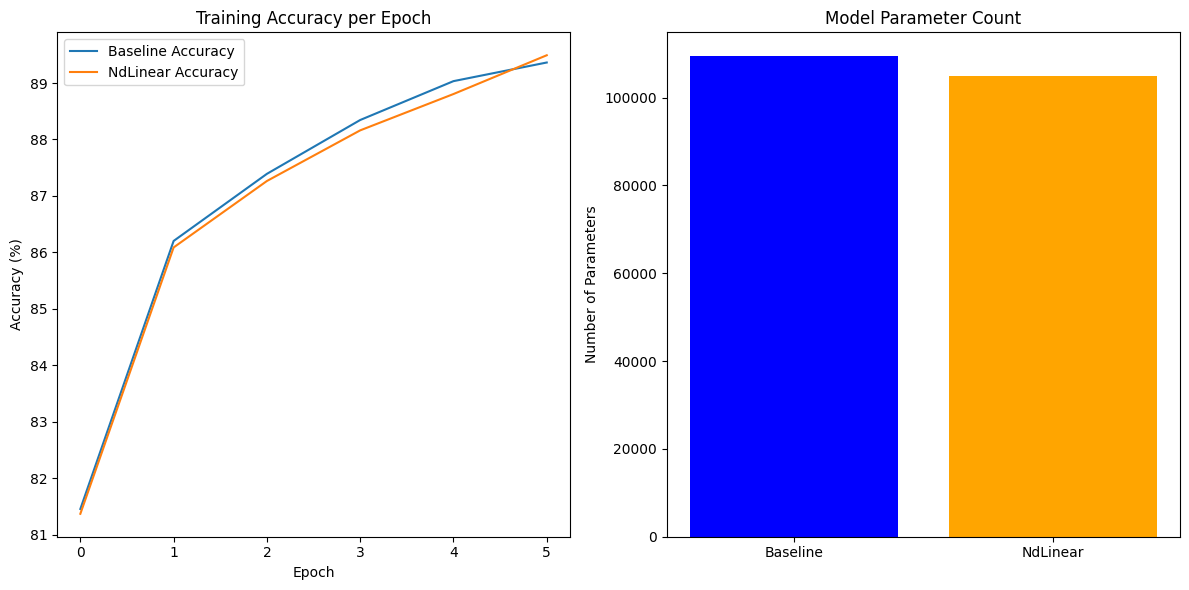

In [16]:
# Plot Training Accuracy and Parameter Count
def plot_results():
    plt.figure(figsize=(12, 6))

    # Accuracy per Epoch
    plt.subplot(1, 2, 1)
    plt.plot(base_accuracies, label='Baseline Accuracy')
    plt.plot(ndl_accuracies, label='NdLinear Accuracy')
    plt.title("Training Accuracy per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()

    # Parameter Count Comparison
    plt.subplot(1, 2, 2)
    plt.bar(["Baseline", "NdLinear"], [count_params(baseline_model), count_params(ndlinear_model)],
            color=["blue", "orange"])
    plt.title("Model Parameter Count")
    plt.ylabel("Number of Parameters")

    plt.tight_layout()
    plt.show()

plot_results()


In [18]:
# Create Summary Table
comparison = pd.DataFrame({
    "Metric": ["Parameter Count", "Training Time (s)", "Inference Time (s)", "Final Accuracy (%)"],
    "BaselineNN": [
        count_params(baseline_model),
        base_train_time,
        base_infer_time,
        base_accuracies[-1]
    ],
    "NdLinearNN": [
        count_params(ndlinear_model),
        ndl_train_time,
        ndl_infer_time,
        ndl_accuracies[-1]
    ]
})

print("\n Benchmark Comparison:\n")
print(comparison)



 Benchmark Comparison:

               Metric     BaselineNN     NdLinearNN
0     Parameter Count  109386.000000  104938.000000
1   Training Time (s)      17.955862      17.532431
2  Inference Time (s)       2.329680       2.323791
3  Final Accuracy (%)      89.363333      89.491667
